# ファクター検証　（reprisk）

`input/msci_india_imi/alpha/reprisk/repr_current_rri`（RepRisk Index, RRI）の検証

## スコアとサイズの相関

### 目的

`02_distribution.ipynb` で、RRI が高い銘柄ほど大型（ゼロ帯の相対サイズ 0.56、25–49 帯 2.9）という構造が見えた。
RRI は報道量に比例するため、サイズとの関係には

- 「大きいほど報道される」という機械的な部分（中立化すべきノイズ）
- 「大きいほど実際にリスク事案が多い」という実質的な部分（情報かもしれない）

が混ざる。IC・分位分析に進む前に、サイズ依存の強さと構造を定量化し、サイズ中立化の方針を決める。

### 定義

サイズの代理として `univ/` のウェイト $w_{i,t}$（浮動株調整後時価総額に比例）を使い、$\log w_{i,t}$ をサイズ変数とする
（時価総額そのものとは定数差なので、順位や回帰には影響しない）。

観測の半分がゼロなので、単純な相関は「ゼロか非ゼロか」とサイズの関係でほぼ決まる。そこで 2 段階に分解する。

1. **発生**: サイズ分位ごとの非ゼロ比率 $P(\text{RRI} > 0 \mid \text{size})$
2. **水準**: 非ゼロ銘柄に限った RRI とサイズの順位相関

さらに、サイズ中立化した RRI（$\log w$ への回帰残差、およびサイズ分位内の順位）を作り、
中立化後にサイズとの相関が消えることを確認する。

In [ ]:
import matplotlib.pyplot as plt
import japanize_matplotlib  # noqa: F401  日本語ラベル用
import numpy as np
import pandas as pd

from alphaeval import InputStore

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)

# ---- パラメータ（別のファクターを検証する場合はここを変える）
INPUT_ROOT = "../../input/msci_india_imi"
SCORE = "reprisk/repr_current_rri"
BENCHMARK = "msci_india"
START, END = 200801, None  # 2007 年はユニバースが小さいので除外（01_coverage の所見）
N_SIZE_BINS = 5

store = InputStore(INPUT_ROOT)


### 1. データ読み込み

`02_distribution.ipynb` と同じ絞り込みに加え、2007 年を除外する。

In [ ]:
univ = store.universe(START, END)
bm = store.benchmark(BENCHMARK, START, END)
score = store.alpha(SCORE, START, END)

score_dates = score.index[score.notna().any(axis=1)]
period = slice(score_dates.min(), score_dates.max())
univ_p, bm_p, score_p = univ.loc[period], bm.loc[period], score.loc[period]
score_u = score_p.where(univ_p.notna())                # ユニバース内のスコア
log_size = np.log(univ_p.where(univ_p > 0))            # サイズ変数（log ウェイト）
in_bm = bm_p.reindex(index=univ_p.index, columns=univ_p.columns).notna()
print(f"評価期間: {period.start.date()} 〜 {period.stop.date()}  ({len(univ_p)} か月)")


評価期間: 2008-01-31 〜 2026-07-31  (223 か月)


### 2. 月次クロスセクション相関の時系列

各月について、ユニバース内でスコアのある銘柄を対象に

- Spearman 相関（RRI vs log サイズ）: 全銘柄
- Spearman 相関: 非ゼロ銘柄のみ
- 点双列相関に相当する「非ゼロダミー vs log サイズ」の相関

を計算する。

,count,mean,std,min,25%,50%,75%,max
全銘柄（Spearman）,223.0,0.377,0.052,0.244,0.342,0.384,0.411,0.491
非ゼロ銘柄のみ（Spearman）,223.0,0.251,0.096,0.010,0.176,0.249,0.325,0.513
非ゼロダミー vs サイズ（Pearson）,223.0,0.365,0.060,0.224,0.318,0.367,0.411,0.515


,全銘柄（Spearman）,非ゼロ銘柄のみ（Spearman）,非ゼロダミー vs サイズ（Pearson）
2008,0.382,0.395,0.418
2009,0.397,0.150,0.424
2010,0.355,0.249,0.378
2011,0.411,0.160,0.422
2012,0.389,0.246,0.377
2013,0.422,0.340,0.384
2014,0.450,0.171,0.467
2015,0.377,0.312,0.362
2016,0.406,0.290,0.401
2017,0.405,0.237,0.405


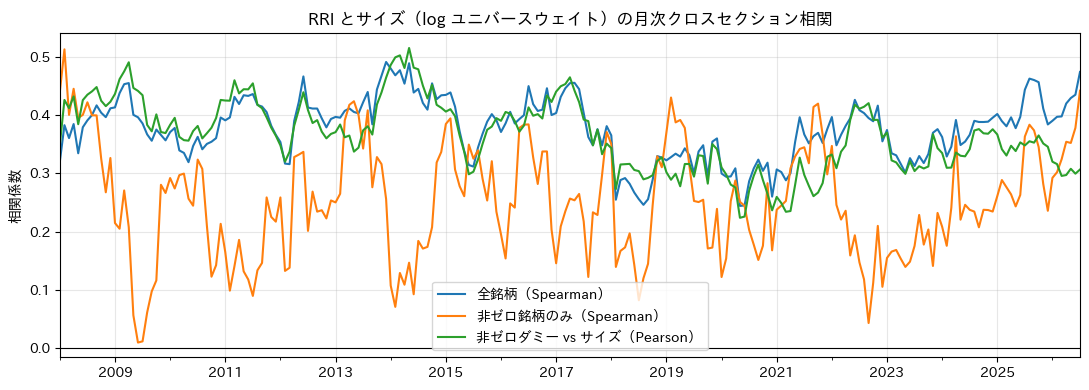

In [ ]:
def row_corr(a: pd.DataFrame, b: pd.DataFrame, method: str = "spearman") -> pd.Series:
    """行（日付）ごとのクロスセクション相関。両方が非欠損の銘柄で計算する。

    Spearman は順位化してから Pearson を取る（同順位は平均順位）。
    """
    out = {}
    for d in a.index:
        x, y = a.loc[d], b.loc[d]
        m = x.notna() & y.notna()
        if m.sum() < 10:
            out[d] = np.nan
            continue
        x, y = x[m], y[m]
        if method == "spearman":
            x, y = x.rank(), y.rank()
        out[d] = x.corr(y)
    return pd.Series(out)

nonzero = score_u.where(score_u > 0)
corr_ts = pd.DataFrame(
    {
        "全銘柄（Spearman）": row_corr(score_u, log_size),
        "非ゼロ銘柄のみ（Spearman）": row_corr(nonzero, log_size),
        "非ゼロダミー vs サイズ（Pearson）": row_corr((score_u > 0).astype(float).where(score_u.notna()), log_size, "pearson"),
    }
)
display(corr_ts.describe().round(3).T)
display(corr_ts.groupby(corr_ts.index.year).mean().round(3))

ax = corr_ts.plot(figsize=(11, 4))
ax.axhline(0, color="k", linewidth=0.8)
ax.set_ylabel("相関係数")
ax.set_title("RRI とサイズ（log ユニバースウェイト）の月次クロスセクション相関")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 3. 2 段階の分解: サイズ分位 × 発生 / 水準

各月、ユニバース内（スコアの有無を問わない）でサイズ 5 分位を切る（S1 = 最小、S5 = 最大）。
分位ごとに

- スコアが存在する割合（カバレッジ）
- スコアが非ゼロの割合（スコアあり銘柄の中で）
- 非ゼロ銘柄の RRI の中央値・平均

を集計する。

,平均銘柄数,カバレッジ,非ゼロ比率（スコアあり内）,非ゼロ RRI 中央値,非ゼロ RRI 平均,RRI 平均（ゼロ含む）
サイズ分位,,,,,,
S1,74.677,0.545,0.294,15.738,15.874,4.661
S2,75.090,0.623,0.315,15.610,15.333,4.911
S3,75.085,0.676,0.322,16.067,15.807,5.131
S4,75.090,0.800,0.442,17.601,17.199,7.729
S5,75.484,0.947,0.720,20.767,20.306,14.682


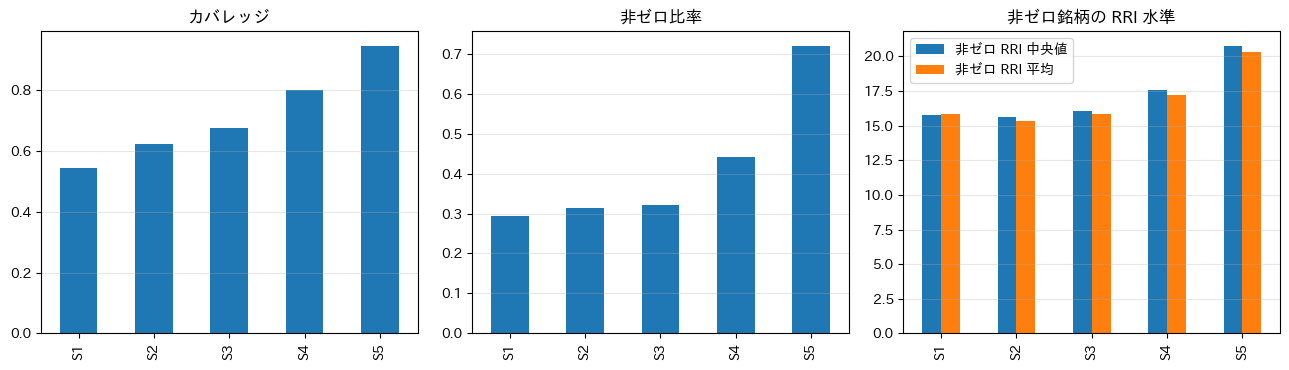

In [ ]:
size_rank = log_size.rank(axis=1, pct=True)
size_bin = np.ceil(size_rank * N_SIZE_BINS).clip(1, N_SIZE_BINS)
size_labels = {k: f"S{k}" for k in range(1, N_SIZE_BINS + 1)}

rows = []
for k in range(1, N_SIZE_BINS + 1):
    m = size_bin == k
    s = score_u.where(m)
    n_univ = m.sum(axis=1)
    n_scored = s.notna().sum(axis=1)
    n_nonzero = (s > 0).sum(axis=1)
    rows.append(
        {
            "サイズ分位": size_labels[k],
            "平均銘柄数": n_univ.mean(),
            "カバレッジ": (n_scored / n_univ).mean(),
            "非ゼロ比率（スコアあり内）": (n_nonzero / n_scored.where(n_scored > 0)).mean(),
            "非ゼロ RRI 中央値": s.where(s > 0).median(axis=1).mean(),
            "非ゼロ RRI 平均": s.where(s > 0).mean(axis=1).mean(),
            "RRI 平均（ゼロ含む）": s.mean(axis=1).mean(),
        }
    )
by_size = pd.DataFrame(rows).set_index("サイズ分位").round(3)
display(by_size)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
by_size["カバレッジ"].plot.bar(ax=axes[0], title="カバレッジ")
by_size["非ゼロ比率（スコアあり内）"].plot.bar(ax=axes[1], title="非ゼロ比率")
by_size[["非ゼロ RRI 中央値", "非ゼロ RRI 平均"]].plot.bar(ax=axes[2], title="非ゼロ銘柄の RRI 水準")
for ax in axes:
    ax.grid(alpha=0.3, axis="y")
    ax.set_xlabel("")
plt.tight_layout()
plt.show()


サイズ分位ごとの非ゼロ比率の推移。サイズ依存が時期によって変わるか（カバレッジ拡張の影響）を見る。

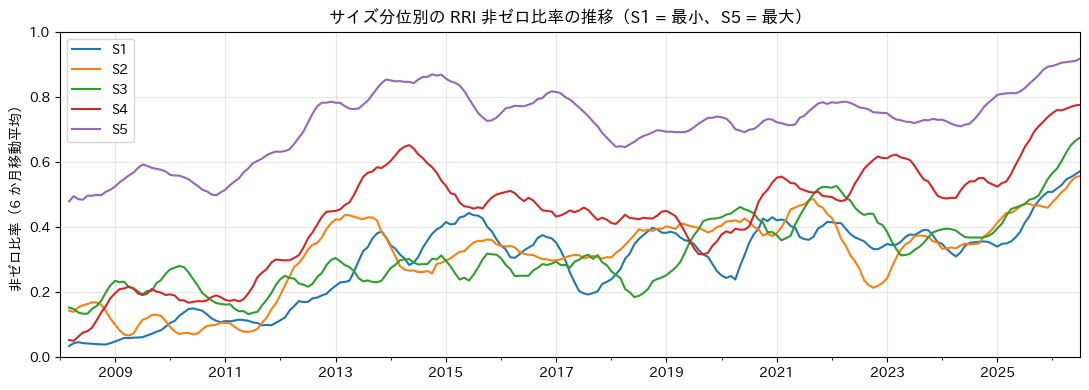

In [ ]:
nonzero_share_ts = pd.DataFrame(
    {
        size_labels[k]: (score_u.where(size_bin == k) > 0).sum(axis=1) / score_u.where(size_bin == k).notna().sum(axis=1)
        for k in range(1, N_SIZE_BINS + 1)
    }
)
ax = nonzero_share_ts.rolling(6, min_periods=3).mean().plot(figsize=(11, 4))
ax.set_ylim(0, 1)
ax.set_ylabel("非ゼロ比率（6 か月移動平均）")
ax.set_title("サイズ分位別の RRI 非ゼロ比率の推移（S1 = 最小、S5 = 最大）")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 4. サイズ分位 × RRI 帯のクロス表

各月の銘柄数を全期間で平均したクロス表。サイズ最小分位に「25 以上」の銘柄がほとんど無ければ、
サイズ中立化してもその層では RRI に情報が無いことになる。

In [ ]:
BANDS = [(-0.5, 0.5, "0"), (0.5, 24.5, "1–24"), (24.5, 49.5, "25–49"), (49.5, 100.5, "50+")]
band_labels = [b[2] for b in BANDS]
band = pd.cut(score_u.stack(), bins=[b[0] for b in BANDS] + [BANDS[-1][1]], labels=band_labels)
band = band.unstack().reindex(index=score_u.index, columns=score_u.columns)

cross = pd.DataFrame(
    {
        lab: [(band.where(size_bin == k) == lab).sum(axis=1).mean() for k in range(1, N_SIZE_BINS + 1)]
        for lab in band_labels
    },
    index=[size_labels[k] for k in range(1, N_SIZE_BINS + 1)],
)
cross["スコアなし"] = [(size_bin == k).sum(axis=1).mean() - score_u.where(size_bin == k).notna().sum(axis=1).mean() for k in range(1, N_SIZE_BINS + 1)]
print("平均銘柄数（月あたり）")
display(cross.round(1))
print("行方向の構成比")
display(cross.div(cross.sum(axis=1), axis=0).round(3))


平均銘柄数（月あたり）


,0,1–24,25–49,50+,スコアなし
S1,26.9,10.7,1.3,0.0,35.7
S2,30.2,13.4,1.2,0.0,30.2
S3,32.5,14.9,1.7,0.0,26.0
S4,31.3,23.2,3.7,0.1,16.7
S5,19.1,39.6,11.7,0.5,4.6


行方向の構成比


,0,1–24,25–49,50+,スコアなし
S1,0.360,0.144,0.018,0.000,0.478
S2,0.402,0.178,0.016,0.000,0.403
S3,0.433,0.199,0.023,0.000,0.346
S4,0.417,0.310,0.049,0.001,0.223
S5,0.253,0.525,0.155,0.006,0.061


### 5. サイズ中立化の予備確認

2 通りの中立化を試し、中立化後のスコアとサイズの相関が消えることを確認する。

- **回帰残差**: 各月、スコアあり銘柄で $\text{RRI}_i = a + b \log w_i + \varepsilon_i$ を推定し、残差 $\varepsilon_i$ を使う
- **サイズ分位内順位**: 各月、サイズ分位ごとに RRI のパーセンタイル順位を取る

ただし RRI の半分がゼロなので、回帰残差は「ゼロ銘柄の残差 = $-(a + b \log w_i)$」となり、
ゼロ銘柄の中で小型ほど残差が高く（= リスクが低いと評価され）なる点に注意する。

,count,mean,std,min,25%,50%,75%,max
生の RRI,223.0,0.377,0.052,0.244,0.342,0.384,0.411,0.491
回帰残差,223.0,-0.140,0.105,-0.444,-0.171,-0.108,-0.062,-0.002
サイズ分位内順位,223.0,-0.049,0.079,-0.293,-0.075,-0.030,0.002,0.155


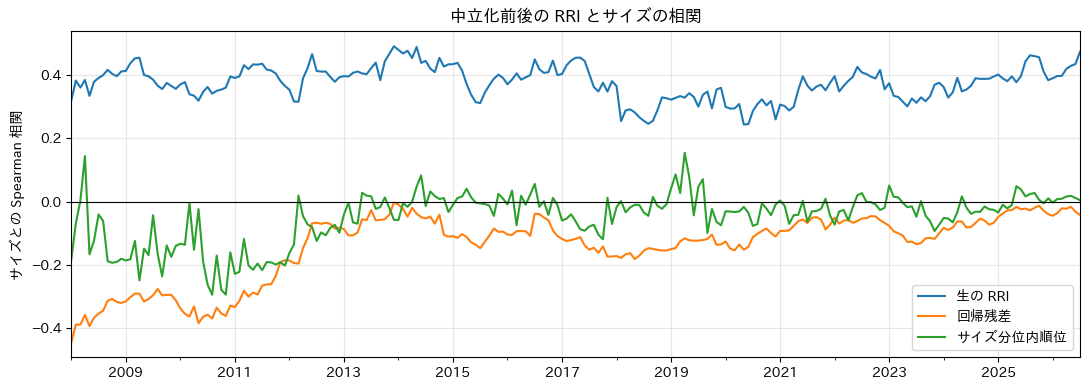

In [ ]:
def neutralize_by_regression(y: pd.DataFrame, x: pd.DataFrame) -> pd.DataFrame:
    """各行で y を x に単回帰した残差を返す（両方が非欠損の銘柄のみ）。"""
    out = pd.DataFrame(np.nan, index=y.index, columns=y.columns)
    for d in y.index:
        yy, xx = y.loc[d], x.loc[d]
        m = yy.notna() & xx.notna()
        if m.sum() < 10:
            continue
        xv, yv = xx[m].to_numpy(), yy[m].to_numpy()
        b = np.cov(xv, yv, ddof=0)[0, 1] / xv.var()
        a = yv.mean() - b * xv.mean()
        out.loc[d, m[m].index] = yv - (a + b * xv)
    return out

def neutralize_by_size_bins(y: pd.DataFrame, bins: pd.DataFrame) -> pd.DataFrame:
    """サイズ分位内でのパーセンタイル順位（0〜1）を返す。"""
    out = pd.DataFrame(np.nan, index=y.index, columns=y.columns)
    for k in np.unique(bins.stack()):
        part = y.where(bins == k)
        out = out.where(bins != k, part.rank(axis=1, pct=True))
    return out

resid = neutralize_by_regression(score_u, log_size)
within = neutralize_by_size_bins(score_u, size_bin)

check = pd.DataFrame(
    {
        "生の RRI": row_corr(score_u, log_size),
        "回帰残差": row_corr(resid, log_size),
        "サイズ分位内順位": row_corr(within, log_size),
    }
)
display(check.describe().round(3).T)
ax = check.plot(figsize=(11, 4))
ax.axhline(0, color="k", linewidth=0.8)
ax.set_ylabel("サイズとの Spearman 相関")
ax.set_title("中立化前後の RRI とサイズの相関")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 6. 所見

**相関の強さ**

- 全銘柄の Spearman 相関は平均 0.38（0.24〜0.49）で、全期間を通じて安定して正。年平均で 0.29〜0.45 の範囲。
- 「非ゼロダミー vs サイズ」が 0.37、「非ゼロ銘柄のみ」が 0.25。**サイズ依存の大半は「ゼロか非ゼロか」で生じている**が、
  非ゼロ銘柄の中でも大型ほど RRI が高い傾向が残る（年により 0.15〜0.40 と変動が大きい）。

**2 段階の分解（サイズ 5 分位）**

| | S1（最小） | S3 | S5（最大） |
| --- | --- | --- | --- |
| カバレッジ | 55% | 68% | 95% |
| 非ゼロ比率（スコアあり内） | 29% | 32% | 72% |
| 非ゼロ RRI 中央値 | 15.7 | 16.1 | 20.8 |
| RRI 平均（ゼロ含む） | 4.7 | 5.1 | 14.7 |

- 非ゼロ比率は S1〜S3 でほぼ横ばい（29〜32%）、S4 で 44%、S5 で 72% と、**最大分位で段差**がある。
  「大型ほど報道される」効果は中大型の中でも特に最上位に集中している。
- 非ゼロ銘柄の RRI 水準は S1〜S3 で 16 前後、S5 で 21 と差は小さい。水準の情報はサイズ横断でおおむね比較可能。
- 時系列では、S5 の非ゼロ比率は 2008 年の 50% から 2014 年に 85%、2026 年に 90% 超へ上昇。
  S1〜S3 は 2008 年の 5〜15% から 2026 年の 55〜65% へ上昇しており、小型のカバレッジ拡張が続いている。
  サイズ依存の構造は期間で変化しており、**サイズ中立化は月ごとに行う**必要がある。

**クロス表**

- S1 で「25 以上」は月平均 1.3 銘柄、S2 で 1.2 銘柄。小型の 2 分位には「中」以上の RRI がほぼ存在しない。
  S5 では 25 以上が 12 銘柄（構成比 16%）。
- S1 は 48% がスコアなし、36% がゼロで、非ゼロは 16% しかない。小型ではスコアあり銘柄の中でも情報量が乏しい。

**中立化の予備確認**

- 回帰残差にしてもサイズとの Spearman 相関が −0.14 残る。ゼロ銘柄の残差が $-(a + b\log w)$ で小型ほど高くなり、
  ゼロ質量が線形回帰では消えないため。**線形残差は RRI には不向き**。
- サイズ分位内順位でも −0.05 残る。分位内の同順位（ゼロ群）の平均順位が分位ごとに異なる（小型分位ではゼロが多く
  平均順位が高い、大型分位ではゼロが少なく平均順位が低い）ことによる。

**後続ステップへの方針**

1. サイズ効果の切り分けは「サイズ分位内での比較」を基本にする。ただしゼロ群の扱いを揃えるため、
   (a) 各サイズ分位内で「ゼロ / 非ゼロ」を分け、非ゼロの中だけ順位を付ける、
   (b) 分位分析はサイズ分位ごとに RRI 帯（ゼロ / 1–24 / 25 以上）のリターンを比較する、の 2 通りを試す。
2. 小型 2 分位（S1、S2）は「25 以上」がほぼ無く、スコアなしも半数近い。RRI の検証はまず
   **S3〜S5（またはベンチマーク内）** で行い、小型は「ゼロ vs 非ゼロ」の比較に限定する。
3. IC は生の RRI とサイズ分位内順位の両方で計算し、差分をサイズ効果の寄与として報告する。